### Data Exploration

In [1]:
from datasets import load_dataset
import pandas as pd

# Load Amazon Polarity dataset
print("Downloading dataset...")
dataset = load_dataset("amazon_polarity")

print("\n" + "="*50)
print("Dataset structure:")
print("="*50)
print(dataset)

print("\n" + "="*50)
print("First training example:")
print("="*50)
print(dataset['train'][0])

print("\n" + "="*50)
print("Dataset sizes:")
print("="*50)
print(f"Training samples: {len(dataset['train']):,}")
print(f"Test samples: {len(dataset['test']):,}")

print("\n" + "="*50)
print("Label distribution in training set:")
print("="*50)
train_df = pd.DataFrame(dataset['train'][:10000])  # Check first 10k
print(train_df['label'].value_counts())

/opt/homebrew/Caskroom/miniconda/base/envs/bert-sentiment/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

First training example:
{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}

Dataset sizes:
Training samples: 3,600,000
Test samples: 400,000

Label distribution in training set:
label
0    5097
1    4903
Name: count, dtype: int64


In [2]:
sample_df = pd.DataFrame(dataset['train'][:5000])
sample_df.head()

,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [3]:
sample_df.iloc[0,2]

'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'

In [4]:
sample_df['text'] = sample_df['title'] + " " + sample_df['content']
sample_df['text_length'] = sample_df['text'].apply(len)
sample_df['text_length'].describe()

count    5000.000000
mean      433.491200
std       236.217292
min       100.000000
25%       236.000000
50%       387.000000
75%       596.000000
max      1013.000000
Name: text_length, dtype: float64

In [5]:
sample_df['word_count'] = sample_df['text'].apply(lambda x: len(x.split()))
sample_df.head()


,label,title,content,text,text_length,word_count
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,Stuning even for the non-gamer This sound trac...,425,80
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,The best soundtrack ever to anything. I'm read...,508,97
2,1,Amazing!,This soundtrack is my favorite music of all ti...,Amazing! This soundtrack is my favorite music ...,759,129
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,Excellent Soundtrack I truly like this soundtr...,742,118
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...","Remember, Pull Your Jaw Off The Floor After He...",480,87


In [6]:
sample_df['word_count'].describe()

count    5000.000000
mean       78.931600
std        42.627009
min        15.000000
25%        43.000000
50%        70.000000
75%       108.000000
max       200.000000
Name: word_count, dtype: float64

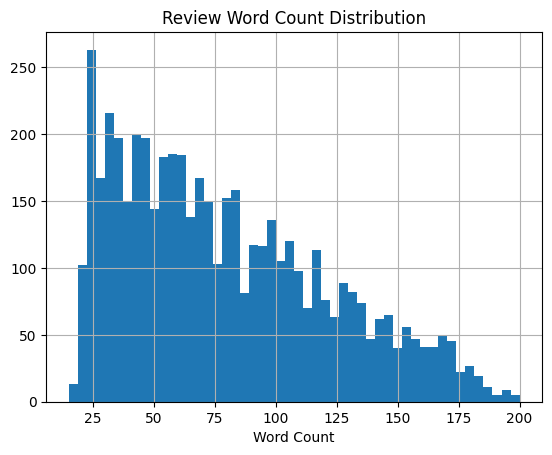

In [8]:
import matplotlib.pyplot as plt

sample_df['word_count'].hist(bins=50)
plt.xlabel('Word Count')
plt.title('Review Word Count Distribution')
plt.show()

In [9]:
sample_df.isna().sum()

label          0
title          0
content        0
text           0
text_length    0
word_count     0
dtype: int64

In [11]:
sample_df.duplicated(keep="first").sum()

np.int64(0)